# Fiberglass Braid Sleeve Nosecone Calculator

This notebook estimates:

1. **Cut length at the COTS diameter** needed for a sleeve to conform to an arbitrary nosecone radius profile.
2. **Dry fabric mass** from sleeve weight (oz/yd²).
3. **Thickness versus axial position** for a specified layer count.
4. A plot of the mandrel diameter, braid stretch/compression, and estimated thickness.

## Important modeling idea

A biaxial sleeve is approximately a pair of helical fiber families. When its diameter changes, the helix angle changes and the sleeve also changes length. Therefore the required cut length is **not** simply the surface arc length divided by the COTS circumference.

The first-pass model below assumes the fibers are inextensible and starts from a nominal braid angle (45° by default). This is a geometric model, not a substitute for actual sleeve measured behavior. The notebook therefore also includes an empirical thickness model that can be calibrated from minor/major diameter test pieces.

### Resources I found while looking up how to model a woven sleeve

https://en.wikipedia.org/wiki/Chinese_finger_trap (first thing I could think of that got me the right terminology to look up)

https://www.sciencedirect.com/topics/engineering/biaxial-braid

https://journals.sagepub.com/doi/pdf/10.1177/096739111702500501 <-- very good, need to read more. closest model i could find on localized stretching/compressing, but theirs is on bending and not changing diameter

https://www.researchgate.net/publication/351753895_Numerical_Simulation_and_Experimental_Study_on_Axial_Stiffness_and_Stress_Deformation_of_the_Braided_Corrugated_Hose/link/67ef00fc9b1c6c487774db58/download

You'd think there'd be more on this subject but it was actually quite hard to find any research papers on modeling braided biaxial sleeve. Especially dry and not doing any FEA or stress testing. 


## 1. User inputs

All dimensions below use inches. The code internally keeps the geometry in inches so that the cloth weight calculation can directly use oz/yd².


In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import fsolve
from dataclasses import dataclass


# Sleeve inputs
# Radius at the COTS diameter is NOT assumed to equal the mold radius.
# COTS diameter is only the reference state of the sleeve
SLEEVE_DIAMETER = 1.75#7    # in # may also be referred to as COTS diameter as the actual sleeve diameter is able to change
SLEEVE_MIN_DIA = 0.75#3.1   # in
SLEEVE_MAX_DIA = 2.25#8.4   # in 

CLOTH_WEIGHT = 10.95       # oz/yd^2 #10.3

# Nominal braid angle at the COTS diameter
BRAID_ANGLE_DEG = 45.0

# Mold & layup

LAYERS = 3
MOLD_MIN_DIA = SLEEVE_MIN_DIA   # in
MOLD_MAX_DIA = 2.2#7            # in


In [61]:
# Nosecone geometry 
# Some good examples of curves:
# https://en.wikipedia.org/wiki/Nose_cone_design
# the 3 below implemented side by side:
# https://www.desmos.com/calculator/c54crhlnrw

# CURVE_LENGTH is the total axial length of the finished nosecone, including the tip, excluding the MAX_DIA_LEN.
CURVE_LENGTH = 9.2#35       # in

# MIN_DIA_LEN is the desired length of constant MOLD_MIN_DIA section of the mold for sleeve to be cut off and replaced with the tip of the finished nosecone.
MIN_DIA_LEN = 1.5#4         # in

# MAX_DIA_LEN is the desired length of constant MOLD_MAX_DIA section at the aft end of the finished nosecone.
MAX_DIA_LEN = MOLD_MAX_DIA  # in

# pre-built POWER SERIES curve calculated from the curve length and maximum diameter of the mold.
# https://www.desmos.com/calculator/kkg6ezj4j9
def POWER_SERIES(x):
    power = 0.5
    return (MOLD_MAX_DIA/2) * np.power(x/CURVE_LENGTH, power)

# pre-built OGIVE curve calculated from the curve length and maximum diameter of the mold.
# https://www.desmos.com/calculator/wwnnbxdzog
def OGIVE(x):
    L = CURVE_LENGTH
    R = MOLD_MAX_DIA / 2
    k = ((L**2) - (R**2))/(-2*R)
    r = np.sqrt((L**2) + (k**2))
    return np.sqrt((r**2) - ((x-L)**2) ) + k

# pre-built HAACK curve calculated from the curve length and maximum diameter of the mold.
# https://www.desmos.com/calculator/udfhogdown
def HAACK(x):
    C = 0
    theta = np.arccos(1 - (2 * x / CURVE_LENGTH))
    return (MOLD_MAX_DIA / 2) / np.sqrt(np.pi) * np.sqrt(theta - (np.sin(2*theta)/2) + C * np.sin(theta)**3)
    
# for an arbitrary curve, CURVE_FUNCTION models the radius of the nosecone at a given axial position x along the curve.
# the nosecone tip should be at the origin (0,0) and the curve should be defined for x in [0, CURVE_LENGTH].
# feel free to replace the CURVE_FUNCTION body with any other function that meets the above criteria, and the rest of the code will automatically adapt to it.
def CURVE_FUNCTION(x):
    return OGIVE(x)

def calculate_geometry():
    # solve for cutoff axial position where the curve drops beneath the minimum diameter section
    # subtract the minimum diameter radius from the curve function and find the root of the resulting function, should only have one root in the range of [0, CURVE_LENGTH]
    cutoff_x = fsolve(lambda x: CURVE_FUNCTION(x) - (MOLD_MIN_DIA / 2), 0)[0]

    # Length of final curved fiberglass section, meaning excludes the aft constant-diameter section.
    TRANSITION_LENGTH = CURVE_LENGTH - cutoff_x

    # cutoff_delta required to shift the curve and piecewise limits to the left or right based on the desired minimum diameter section length.
    cutoff_delta = cutoff_x - MIN_DIA_LEN
    
    # print(f"Original cutoff x:          {cutoff_x:.3f} in")
    # print(f"Shift amount:               {cutoff_delta:.3f} in")

    return (
        TRANSITION_LENGTH,
        cutoff_x,
        cutoff_delta,
    )

TRANSITION_LENGTH, cutoff_x, cutoff_delta = calculate_geometry()

TOTAL_NOSECONE_LENGTH = CURVE_LENGTH + MAX_DIA_LEN

FIBERGLASS_LENGTH = TRANSITION_LENGTH + MAX_DIA_LEN

MOLD_LENGTH = MIN_DIA_LEN + TRANSITION_LENGTH + MAX_DIA_LEN

print(f"Total nosecone length:      {TOTAL_NOSECONE_LENGTH:.3f} in\n")

print(f"Tip length:                 {CURVE_LENGTH-TRANSITION_LENGTH:.3f} in")
print(f"Transition curve length:    {TRANSITION_LENGTH:.3f} in")
print(f"Maximum diameter length:    {MAX_DIA_LEN:.3f} in\n")

print(f"Fiberglass length:          {FIBERGLASS_LENGTH:.3f} in")
print(f"Total mold length:          {MOLD_LENGTH:.3f} in")

Total nosecone length:      11.400 in

Tip length:                 1.713 in
Transition curve length:    7.487 in
Maximum diameter length:    2.200 in

Fiberglass length:          9.687 in
Total mold length:          11.187 in


## 2. Define the profile

Create a transition radius curve given the `MIN_DIA_LEN` as a horizontal offset for the curve, and have the curve start at the `SLEEVE_MIN_DIA` cutoff 



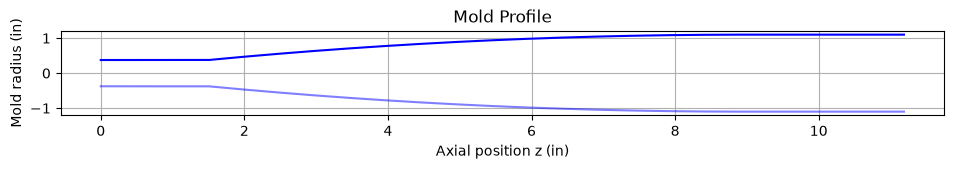

In [62]:
def transition_radius(z):

    z = np.asarray(z)

    # Convert shifted/final coordinate back into the original mathematical von Kármán coordinate. keep x 0 to avoid sqrt of negative numbers error even if not displayed
    x = np.where(z < MIN_DIA_LEN, 0, 
                 z + cutoff_delta)

    # call the curve function to get the radius at the given x position
    return CURVE_FUNCTION(x)


def radius_profile(z):
    """
    Complete shifted piecewise nosecone diameter D(z).

    z = 0                     -> tip
    z = MIN_SECTION            -> start of VK transition
    z = NOSECONE_LENGTH       -> aft/base/coupler section
    """

    z = np.asarray(z)

    return np.where(
        # Constant minimum-diameter section
        z < MIN_DIA_LEN,    SLEEVE_MIN_DIA/2,

        np.where(
            # Von Kármán transition
            z < CURVE_LENGTH-cutoff_delta,  transition_radius(z),

            # Constant maximum-diameter aft section
            MOLD_MAX_DIA/2,
        ),
    )

def dia_profile (z):
    """Return the diameter profile for a given axial position z."""
    return radius_profile(z) * 2

# Quick visual check of the diameter profile.
z_plot = np.linspace(0, MOLD_LENGTH, 1000)
r_plot = radius_profile(z_plot) 


plt.figure(figsize=(TOTAL_NOSECONE_LENGTH, MOLD_MAX_DIA/2))
plt.plot(z_plot, r_plot, color='blue')
plt.plot(z_plot, -r_plot, color='blue', alpha=0.5)
plt.xlabel("Axial position z (in)")
plt.ylabel("Mold radius (in)")
plt.title("Mold Profile")


plt.grid(True)
plt.show()

`Disclaimer: this section was assisted by AI. I am still working on making it more accurate manually. `

`Currently I have no way of knowing how accurate the below numbers are, I am still working on verifying the data below. It appears consistent with expected values for consumption values below, and seems to be close to accurate but not 100% yet.`

## 3. Braid kinematics

- `D0` = COTS diameter
- `D` = local mold diameter
- `θ0` = braid angle at the COTS diameter, measured from the **axis**
- `λθ = D/D0` = circumferential stretch ratio
- `λz` = axial stretch ratio

For an approximately inextensible yarn path, the local deformation satisfies

`λz² cos²(θ0) + λθ² sin²(θ0) = 1`

so:

`λz = sqrt((1 - λθ² sin²(θ0)) / cos²(θ0))`

This is the behavior where a diameter increase forces axial compression, while a diameter decrease allows axial extension.

At 45°, the equation simplifies to `λz = sqrt(2 - λθ²)`.


In [63]:
THETA0 = np.deg2rad(BRAID_ANGLE_DEG)

def circumferential_stretch(diameter):
    """Local diameter / COTS diameter."""
    return np.asarray(diameter) / SLEEVE_DIAMETER


def axial_stretch(diameter):
    """Axial material stretch relative to the COTS state.

    λz > 1 means the sleeve becomes longer locally.
    λz < 1 means the sleeve becomes shorter/compressed locally.
    """
    lam_theta = circumferential_stretch(diameter)

    numerator = 1.0 - lam_theta**2 * np.sin(THETA0)**2
    denominator = np.cos(THETA0)**2

    if np.any(numerator < 0):
        raise ValueError(
            "The requested diameter is outside the geometric "
            "range permitted by the chosen braid angle."
        )

    return np.sqrt(numerator / denominator)


print("Axial stretch at maximum mold diameter:\t\t", axial_stretch(MOLD_MAX_DIA))
print("Axial stretch at minimum mold diameter:\t\t", axial_stretch(MOLD_MIN_DIA),"\n")

print("Axial stretch at maximum sleeve diameter:\t", axial_stretch(SLEEVE_MAX_DIA))
print("Axial stretch at minimum sleeve diameter:\t", axial_stretch(SLEEVE_MIN_DIA))

Axial stretch at maximum mold diameter:		 0.647759088500264
Axial stretch at minimum mold diameter:		 1.3477115902938004 

Axial stretch at maximum sleeve diameter:	 0.5890150893739509
Axial stretch at minimum sleeve diameter:	 1.3477115902938004


`Disclaimer: this section is inaccurate. Do not rely on this to cut layer lengths, it still runs short by a few inches compared to practical values. I can only assume the inaccuracy comes from the stretch model not being entirely accurate`

## 4. Calculate the COTS cut length

If a small piece of the sleeve has axial length `ds0` at its COTS state, then after deformation its axial contribution on the mold is approximately

`dz = λz ds0`.

Therefore the amount of COTS-state sleeve consumed by a small axial section is

`ds0 = dz / λz`.

The total cut length is consequently:

`L_cut = ∫ dz / λz(D(z))`.

Notice that it automatically gives less than one inch of COTS sleeve per inch of mold length in regions where the sleeve is stretched, and more than one inch where it is compressed. More on that in the consumption section below


In [64]:
def cut_length(diameter_function, total_length, samples=5000):
    """Numerically integrate the required COTS-state cut length."""
    z = np.linspace(0.0, total_length, samples)
    d = diameter_function(z)
    local_factor = 1.0 / axial_stretch(d)

    return np.trapezoid(local_factor, z)

CUT_LENGTH = cut_length(dia_profile, MOLD_LENGTH)

print(f"Required cut length: {CUT_LENGTH:.3f} in")
print(f"Required cut length: {CUT_LENGTH/12:.3f} ft")
print(f"Cut-length / finished axial length: "
      f"{CUT_LENGTH/MOLD_LENGTH:.3f}")

Required cut length: 12.771 in
Required cut length: 1.064 ft
Cut-length / finished axial length: 1.142


### Local consumption 

The quantity plotted below is `1/λz`: the number of inches of COTS-state sleeve consumed per inch of mold length. Put simply, it can be intuited as the ratio of 1 inch of sleeve : n inches on the mold. 

consumption < 1 = stretching, COTS length stretches to cover more mold length

consumption = 1 = neutral case, COTS length covers its own length in mold length

consumption > 1 = compressed, COTS length squishes and covers less mold length


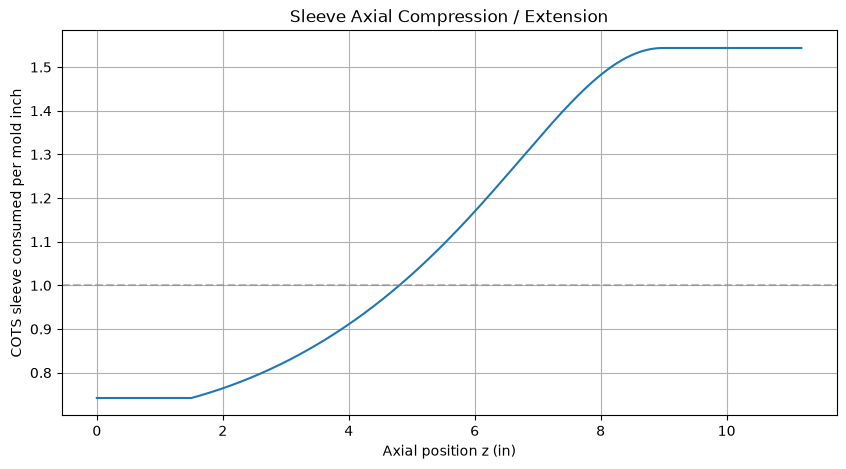

In [65]:
z_plot = np.linspace(0, MOLD_LENGTH, 1000)
d_plot = dia_profile(z_plot)
consumption = 1.0 / axial_stretch(d_plot)

plt.figure(figsize=(10, 5))
plt.plot(z_plot, consumption)
plt.axhline(1.0, linestyle="--", color="gray", alpha=0.5)
plt.xlabel("Axial position z (in)")
plt.ylabel("COTS sleeve consumed per mold inch")
plt.title("Sleeve Axial Compression / Extension")
plt.grid(True)
plt.show()

`Disclaimer: this section is inaccurate due to past sections not being completely accurate. Do not use it yet for any final physical calculations, and please use real material to finalize numbers.`

`Currently the estimated weight is too light compared to measured results. This can be from cut length being inaccurate, mass estimation being inaccurate, cloth density from stretch/compressing estimation, etc. Real parts tend to be heavier than this output, please make sure to weigh anything before doing any critical math surrounding weight`

## 5. Fabric mass

For a sleeve whose COTS diameter is `D0`, the COTS-state fabric area is approximately

`A = π D0 L_cut`.

With cloth weight `W` in oz/yd² and area `A` in in²:

`mass_oz = W A / 1296`.

This is **dry fabric mass for one layer, before resin**. Resin mass can be added separately with a resin/fiber ratio or target fiber-volume fraction.


In [66]:
def fabric_mass_oz(cut_length, cots_diameter, cloth_weight):
    """Dry fabric mass from oz/yd² and COTS-state sleeve area."""
    area_in2 = np.pi * cots_diameter * cut_length
    return cloth_weight * area_in2 / 1296.0


dry_mass_oz = fabric_mass_oz(CUT_LENGTH, SLEEVE_DIAMETER, CLOTH_WEIGHT)

print(f"Dry fabric mass: {dry_mass_oz:.2f} oz")
print(f"Dry fabric mass: {dry_mass_oz/16:.3f} lb")

Dry fabric mass: 0.59 oz
Dry fabric mass: 0.037 lb


`Disclaimer: this section was assisted by AI. I am still working on making it more accurate manually. `

`So far, parts tend to be thicker than the (1.75" -> 7" vastly different sleeve estimate) empirical and thinner than the kinematic model estimates. The truth probably lies somewhere in between if I could refine both approaches. I would recommend doing a min/max diameter test and get measured values for thickness per layer for the sleeve you are using, and replacing the test values for the empirical model which seems to match well enough for modeling`

## 6. Thickness model

There are two useful models here.

### A. Kinematic/area-conservation estimate

If fiber volume is conserved and the fabric's in-plane area changes by approximately `λz λθ`, then a first-order thickness estimate is

`t(D) = t0 / (λz λθ)`.

### B. Empirical power-law model

The 1.75-inch sleeve example gives roughly 0.5 mm/layer at 2.25 inches and 1.0 mm/layer at 0.75 inches. Those two measurements can be used to fit

`t(D) = a D^(-p)`.

This is likely the more useful engineering model once you have your minor/major diameter test data. With three or more measurements we can later fit a more flexible curve.


In [67]:
# ------------------------------------
# Thickness calibration measurements
# ------------------------------------
# Replace these with measured SINGLE-LAYER cured thicknesses.
#
# Example values from the 1.75-inch sleeve experiment:
THICKNESS_TEST_DIAMETERS = np.array([0.75, 2.25]) # in dia
THICKNESS_TEST_VALUES = np.array([1.00, 0.50])  # mm/layer


def fit_power_law(diameters, thicknesses):
    """Fit t = a * D^(-p) using a log-linear least-squares fit."""
    d = np.asarray(diameters, dtype=float)
    t = np.asarray(thicknesses, dtype=float)

    if np.any(d <= 0) or np.any(t <= 0):
        raise ValueError("Diameters and thicknesses must be positive.")

    # log(t) = log(a) - p*log(D)
    slope, intercept = np.polyfit(np.log(d), np.log(t), 1)
    p = -slope
    a = np.exp(intercept)

    return a, p


thickness_a, thickness_p = fit_power_law(
    THICKNESS_TEST_DIAMETERS,
    THICKNESS_TEST_VALUES,
)


def empirical_thickness_per_layer(diameter):
    """Estimated cured thickness per layer in mm."""
    return thickness_a * np.asarray(diameter)**(-thickness_p)


def empirical_total_thickness(diameter, layers):
    """Estimated total cured wall thickness in mm."""
    return layers * empirical_thickness_per_layer(diameter)


print(f"Power-law coefficient a = {thickness_a:.4f}")
print(f"Power-law exponent p = {thickness_p:.4f}\n")

print(
    f"Predicted thickness at COTS diameter "
    f"({SLEEVE_DIAMETER:.2f} in): "
    f"{empirical_thickness_per_layer(SLEEVE_DIAMETER):.3f} mm/layer\n"
)

print(
    f"Predicted total thickness at COTS diameter "
    f"({SLEEVE_DIAMETER:.2f} in): "
    f"{empirical_total_thickness(SLEEVE_DIAMETER, LAYERS):.3f} mm\n"
)
    
print(
    f"Predicted total thickness at minimum diameter "
    f"({SLEEVE_MIN_DIA:.2f} in): "
    f"{empirical_total_thickness(SLEEVE_MIN_DIA, LAYERS):.3f} mm\n"
)
print(
    f"Predicted total thickness at maximum diameter "
    f"({SLEEVE_MAX_DIA:.2f} in): "
    f"{empirical_total_thickness(SLEEVE_MAX_DIA, LAYERS):.3f} mm"
)

Power-law coefficient a = 0.8340
Power-law exponent p = 0.6309

Predicted thickness at COTS diameter (1.75 in): 0.586 mm/layer

Predicted total thickness at COTS diameter (1.75 in): 1.758 mm

Predicted total thickness at minimum diameter (0.75 in): 3.000 mm

Predicted total thickness at maximum diameter (2.25 in): 1.500 mm


### Optional kinematic thickness estimate

This lets you compare an empirical calibration against a simple geometric area-conservation model. Set `REFERENCE_THICKNESS_MM` to a measured thickness at a known reference diameter.


In [68]:
REFERENCE_DIAMETER = SLEEVE_DIAMETER
REFERENCE_THICKNESS_MM = empirical_thickness_per_layer(REFERENCE_DIAMETER)


def kinematic_thickness_per_layer(diameter):
    """Area-conservation thickness estimate in mm/layer."""
    d = np.asarray(diameter, dtype=float)

    ref_area_scale = (
        axial_stretch(REFERENCE_DIAMETER)
        * circumferential_stretch(REFERENCE_DIAMETER)
    )

    local_area_scale = (
        axial_stretch(d)
        * circumferential_stretch(d)
    )

    return REFERENCE_THICKNESS_MM * ref_area_scale / local_area_scale


def kinematic_total_thickness(diameter, layers):
    return layers * kinematic_thickness_per_layer(diameter)

print(
    f"Kinematic thickness at COTS diameter "
    f"({SLEEVE_DIAMETER:.2f} in): "
    f"{kinematic_thickness_per_layer(SLEEVE_DIAMETER):.3f} mm/layer\n"
)
print(
    f"Kinematic total thickness at COTS diameter "
    f"({SLEEVE_DIAMETER:.2f} in): "
    f"{kinematic_total_thickness(SLEEVE_DIAMETER, LAYERS):.3f} mm\n"
)
print(
    f"Kinematic total thickness at minimum diameter "
    f"({SLEEVE_MIN_DIA:.2f} in): "
    f"{kinematic_total_thickness(SLEEVE_MIN_DIA, LAYERS):.3f} mm\n"
)
print(
    f"Kinematic total thickness at maximum diameter "
    f"({SLEEVE_MAX_DIA:.2f} in): "
    f"{kinematic_total_thickness(SLEEVE_MAX_DIA, LAYERS):.3f} mm"
)

Kinematic thickness at COTS diameter (1.75 in): 0.586 mm/layer

Kinematic total thickness at COTS diameter (1.75 in): 1.758 mm

Kinematic total thickness at minimum diameter (0.75 in): 3.043 mm

Kinematic total thickness at maximum diameter (2.25 in): 2.321 mm


## 7. Thickness along the actual nosecone

The empirical model is used by default because the purpose of the test pieces is to characterize the actual commercial sleeve. The result is a wall-thickness estimate before accounting for any intentional sanding, resin-rich areas, local overlap, or shoulder construction.


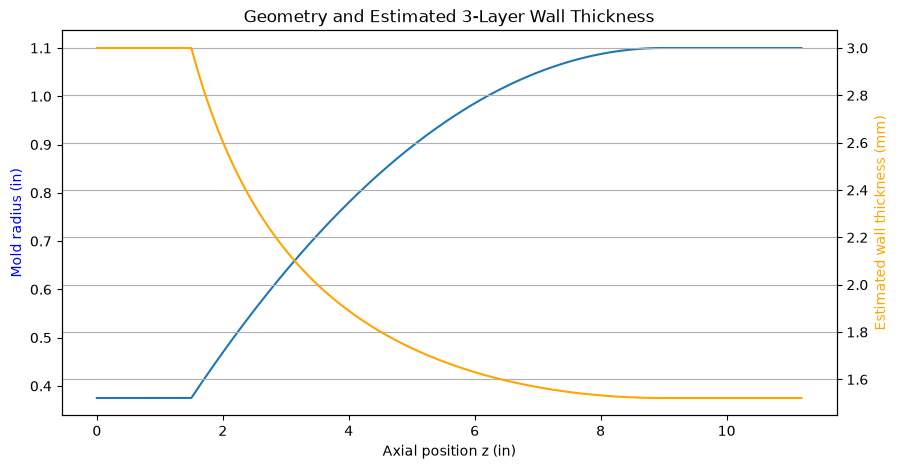

Minimum predicted wall thickness: 1.521 mm
Maximum predicted wall thickness: 3.000 mm


In [69]:
thickness_mm = empirical_total_thickness(d_plot, LAYERS)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(z_plot, r_plot)
ax1.set_xlabel("Axial position z (in)")
ax1.set_ylabel("Mold radius (in)", color="blue")

ax2 = ax1.twinx()
ax2.plot(z_plot, thickness_mm, color="orange")
ax2.set_ylabel("Estimated wall thickness (mm)", color="orange")

plt.title(f"Geometry and Estimated {LAYERS}-Layer Wall Thickness")
plt.grid(True)
plt.show()

print(f"Minimum predicted wall thickness: {thickness_mm.min():.3f} mm")
print(f"Maximum predicted wall thickness: {thickness_mm.max():.3f} mm")

## 8. Convenient Numbers

In [70]:
# Composite FWD outer diameter = MOLD_MIN_DIA + 2* LAYERS * empirical_thickness_per_layer(MOLD_MIN_DIA)
# this is useful for determining the real tip outer diameter of the finished nosecone, which is important for ensuring a proper fit with the rest of the rocket body.

tip_outer_diameter = MOLD_MIN_DIA + 2 * LAYERS * (empirical_thickness_per_layer(MOLD_MIN_DIA)* 0.0393701) # convert mm to in
print(f"Predicted tip outer diameter: {tip_outer_diameter:.3f} in")
print(f"Tip length: {CURVE_LENGTH-TRANSITION_LENGTH:.3f} in") # = cutoff_x 

print(f"Dry sleeve cut length (single layer): {CUT_LENGTH:.3f} in")
print(f"Dry sleeve cut weight (single layer): {fabric_mass_oz(CUT_LENGTH, SLEEVE_DIAMETER, CLOTH_WEIGHT):.3f} oz")
print(f"Estimated total composite weight: {fabric_mass_oz(CUT_LENGTH, SLEEVE_DIAMETER, CLOTH_WEIGHT) * LAYERS * 2 / 16:.3f} lbs") # multiply by 2 for 1:1 resin weight, divide by 16 to convert to lbs

base_outer_diameter = MOLD_MAX_DIA + 2 * LAYERS * (empirical_thickness_per_layer(MOLD_MAX_DIA) * 0.0393701) # convert mm to in
print(f"Predicted base outer diameter: {base_outer_diameter:.3f} in")

Predicted tip outer diameter: 0.986 in
Tip length: 1.713 in
Dry sleeve cut length (single layer): 12.771 in
Dry sleeve cut weight (single layer): 0.593 oz
Estimated total composite weight: 0.222 lbs
Predicted base outer diameter: 2.320 in


In [71]:
# Coordinate convention:
#   x = axial coordinate along the ORIGINAL VK curve
#   y = radius
#   z = 0
#
# The five exported curves are:
#   1. curve -> entire VK curve, x = 0 ... CURVE_LENGTH
#       (effectively r1 + tip)
#   2. r1    -> fiberglass inner face, x = cutoff_x ... CURVE_LENGTH
#   3. r2    -> fiberglass outer face, x = cutoff_x ... CURVE_LENGTH
#   4. tip   -> VK curve from x = 0 ... cutoff_x
#   5. mold  -> entire mold profile, z = 0 ... MOLD_LENGTH
#       (this is the only curve that includes the aft constant-diameter section)

# Choose the resolution of the exported curves
NUM_CSV_POINTS = 1000

# 1. CURVE
# Follow the mathematical VK curve from x = 0 to x = CURVE_LENGTH
# This is the complete mathematical curve before the cutoff/tip modification is applied

curve_x = np.linspace(0.0, CURVE_LENGTH, NUM_CSV_POINTS)

curve_r = CURVE_FUNCTION(curve_x)

curve_data = np.column_stack((curve_x, curve_r, np.zeros_like(curve_x)))

# 2. R1 -- INNER FIBERGLASS FACE/OUTER MOLD FACE ALONG THE TRANSITION CURVE
# The fiberglass begins at the point where the VK curve reaches SLEEVE_MIN_DIA
# Therefore the fiberglass inner face runs from:
#     x = cutoff_x
#     x = CURVE_LENGTH

r1_x = np.linspace(cutoff_x, CURVE_LENGTH, NUM_CSV_POINTS)

r1_r = CURVE_FUNCTION(r1_x)

# add MAX_DIA_LEN in 

r1_data = np.column_stack((r1_x, r1_r, np.zeros_like(r1_x)))

# 3. R2 -- OUTER FIBERGLASS FACE
# the mold radius plus the estimated wall thickness
#
# CURVE_FUNCTION returns radius in inches.
# empirical_total_thickness() expects DIAMETER and returns mm.
#
# Therefore:
#     radius -> diameter
#             -> thickness in mm
#             -> thickness in inches
#             -> add to radius

r2_x = r1_x.copy()

r2_inner_r = r1_r.copy()

# Convert radius to diameter for the thickness model
r1_diameter = 2.0 * r2_inner_r

# Get total wall thickness for the requested number of layers
# empirical_total_thickness() returns millimeters
r2_thickness_mm = empirical_total_thickness(r1_diameter, LAYERS)

# Convert millimeters to inches
r2_thickness_in = r2_thickness_mm / 25.4

# Move radially outward by the wall thickness
r2_r = r2_inner_r + r2_thickness_in

r2_data = np.column_stack((r2_x, r2_r, np.zeros_like(r2_x)))

# 4. TIP
# The tip is the portion of the VK curve BEFORE the fiberglass cutoff.
#
# This follows the original curve from:
#     x = 0
#     x = cutoff_x
#
# The endpoint at cutoff_x therefore has radius:
#     SLEEVE_MIN_DIA / 2 + estimated wall thickness at SLEEVE_MIN_DIA

tip_x = np.linspace(0.0, cutoff_x, NUM_CSV_POINTS)

tip_r = CURVE_FUNCTION(tip_x)

# tip_r needs to be linearly remapped such that x=0 stays at y=0 
# but x=cutoff_x is at the r2 min radius to account for the thickness of the fiberglass at the cutoff point. 
# This ensures that the tip connects smoothly to the fiberglass section.
# all intermediary points are linearly interpolated between these two endpoints.
# basically just push the end of tip_r to the r2 radius at cutoff_x and scale all other points accordingly.
tip_r = tip_r * (r2_r[0] / tip_r[-1])

tip_data = np.column_stack((tip_x, tip_r, np.zeros_like(tip_x)))

# 5. MOLD
# This follows the piecewise radius profile from z = 0 to z = MOLD_LENGTH, the same curve plotted in the original profile definition
mold_x = np.linspace(0.0, MOLD_LENGTH, NUM_CSV_POINTS)
mold_r = radius_profile(mold_x)
mold_data = np.column_stack((mold_x, mold_r, np.zeros_like(mold_x)))

# SAVE CSV FILES

np.savetxt("curve.csv", curve_data, delimiter=",", fmt="%.6f")
np.savetxt("r1.csv", r1_data, delimiter=",", fmt="%.6f")
np.savetxt("r2.csv", r2_data, delimiter=",", fmt="%.6f")
np.savetxt("tip.csv", tip_data, delimiter=",", fmt="%.6f")
np.savetxt("mold.csv", mold_data, delimiter=",", fmt="%.6f")

# VALIDATE THE CSV FILES

csv_files = ["curve.csv", "r1.csv", "r2.csv", "tip.csv", "mold.csv"]

for filename in csv_files:

    data = np.loadtxt(filename, delimiter=",")

    if np.isnan(data).any() or np.isinf(data).any():
        print(f"{filename} contains NaNs or Infs")

    elif data.shape[1] != 3:
        print(f"{filename} does not have exactly 3 columns")

    else:
        print(
            f"✓ {filename}: "
            f"{len(data)} points, "
            f"x = {data[:, 0].min():.3f} → {data[:, 0].max():.3f} in"
        )

✓ curve.csv: 1000 points, x = 0.000 → 9.200 in
✓ r1.csv: 1000 points, x = 1.713 → 9.200 in
✓ r2.csv: 1000 points, x = 1.713 → 9.200 in
✓ tip.csv: 1000 points, x = 0.000 → 1.713 in
✓ mold.csv: 1000 points, x = 0.000 → 11.187 in
